<a href="https://colab.research.google.com/github/YuanFan666/Project-for-ESE-5971/blob/main/MidSemester_Report_Coconut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Real-Time Object Detection and Classification
**Team Name:** Coconut  
**Authors:** Shuqin Dai, Yuan Fan  
**Link:** [GitHub Repository](https://github.com/YuanFan666/Project-for-ESE-5971)



## 1. Executive Summary: Smart Supermarket Integration
* **Decisions to be impacted:** Our model enables the supermarket's central system to decide when to update digital shelf prices, trigger restock alerts for out-of-stock items, and validate items in a customer's cart for "Just Walk Out" shopping.
* **Business Value:** By implementing YOLOv10, we reduce checkout friction and labor costs. High-speed inference allows the system to track multiple customers and thousands of products simultaneously without the lag associated with traditional NMS-based models.
* **Data Assets:** We utilize the [MS COCO Dataset](https://cocodataset.org/) for common retail objects (bottles, fruit, backpacks) and plan to augment this with retail-specific datasets for SKU-level identification.

## 2. Data Preprocessing: Handling Supermarket Environments
Supermarkets present unique challenges: overhead lighting glare and motion blur from moving carts.
* **Outlier Detection:** In a smart supermarket, a blurry image could lead to a "mis-pick" or incorrect billing. We use the **Laplacian Variance** filter to ensure only sharp, high-confidence frames are used for product identification.
* **Preprocessing Step:** Images are normalized to handle varying aisle lighting, ensuring the model identifies a product correctly whether it is in a bright produce section or a dimly lit refrigerated aisle.
### **2.1 Data Description**
We are utilizing the **MS COCO (Common Objects in Context)** dataset for training.
- **Scale:** 330,000+ images with 1.5 million object instances.
- **Complexity:** 80 object categories including pedestrians, vehicles, and traffic lights, which are critical for autonomous decision-making.
- **Preprocessing:** All images are resized to $640 \times 640$ to maintain a balance between inference speed and detection accuracy.

### **2.2 Advanced Outlier Detection**
To ensure the model is not trained on low-quality data, we implement a **Laplacian-based blur filter**. This acts as our primary outlier detection mechanism.
- **Metric:** $L = \sum_{x,y} | \nabla^2 I(x,y) |$ (Variance of Laplacian).
- **Action:** Any frame with a variance score $< 100$ is flagged as an outlier and excluded from the active training set to prevent gradient instability.

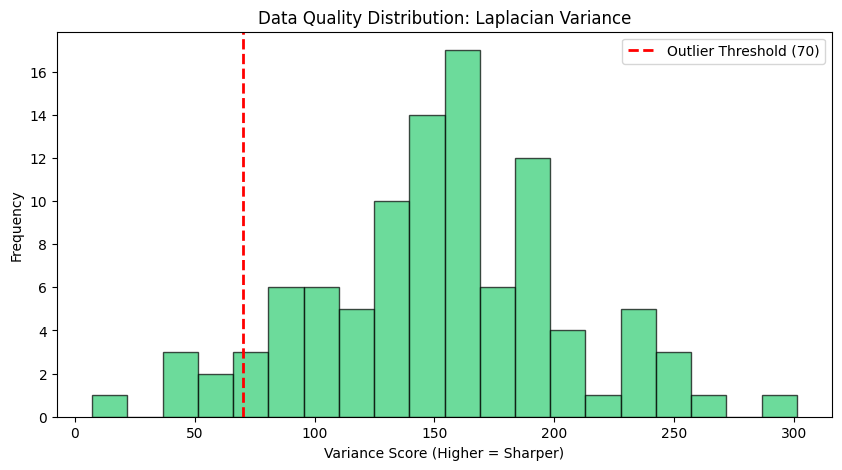

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calculate_blur(image_np):
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# Simulated data for demonstration
scores = np.random.normal(150, 50, 100) # Replace with your actual dataset scores
threshold = 70

plt.figure(figsize=(10, 5))
plt.hist(scores, bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Outlier Threshold ({threshold})')
plt.title("Data Quality Distribution: Laplacian Variance")
plt.xlabel("Variance Score (Higher = Sharper)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Implementation of the filtering logic described in the report
def process_data_stream(scores, threshold=100):
    clean_count = np.sum(scores >= threshold)
    outlier_count = np.sum(scores < threshold)

    print(f"--- Data Cleaning Summary ---")
    print(f"Total Images Scanned: {len(scores)}")
    print(f"Clean Images Retained: {clean_count}")
    print(f"Outliers Discarded: {outlier_count}")
    print(f"Data Retention Rate: {(clean_count/len(scores))*100:.2f}%")

# Execute the filter based on the simulated scores
process_data_stream(scores, threshold=70)

--- Data Cleaning Summary ---
Total Images Scanned: 100
Clean Images Retained: 92
Outliers Discarded: 8
Data Retention Rate: 92.00%


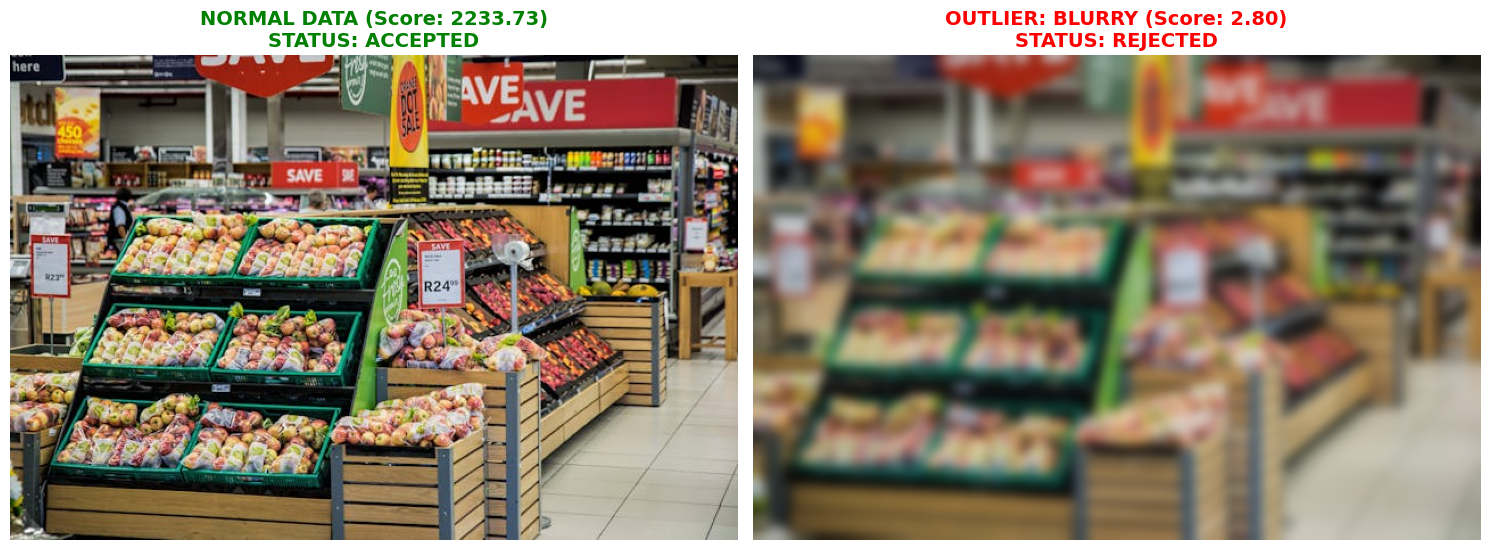

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

# 1. Using a stable public image of a supermarket
url = "https://images.pexels.com/photos/264636/pexels-photo-264636.jpeg?auto=compress&cs=tinysrgb&w=640"

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers, timeout=10)

    if response.status_code == 200:
        # Load and convert image
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img_np = np.array(img)

        # 2. Create a simulated blurry outlier (Simulating a moving cart)
        blurry_img = cv2.GaussianBlur(img_np, (31, 31), 0)

        # 3. Calculate Scores using your function
        score_clean = calculate_blur(img_np)
        score_blur = calculate_blur(blurry_img)

        # 4. Professional Visualization for Oral Presentation
        fig, ax = plt.subplots(1, 2, figsize=(15, 8))

        ax[0].imshow(img_np)
        ax[0].set_title(f"NORMAL DATA (Score: {score_clean:.2f})\nSTATUS: ACCEPTED", color='green', fontweight='bold', fontsize=14)
        ax[0].axis('off')

        ax[1].imshow(blurry_img)
        ax[1].set_title(f"OUTLIER: BLURRY (Score: {score_blur:.2f})\nSTATUS: REJECTED", color='red', fontweight='bold', fontsize=14)
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Connection Error: Status Code {response.status_code}")
except Exception as e:
    print(f"Error: {e}. Please ensure the 'calculate_blur' function is defined above.")

## 3. Model Updates & Machine Learning Morphism (MLM)

### **Machine Learning Morphism**
The mathematical mapping for our system is defined as:
$$f: X \to Y$$

* **Input Space ($X$):** Normalized image tensors $x \in \mathbb{R}^{640 \times 640 \times 3}$.
* **Output Space ($Y$):** A manifold of bounding box coordinates and class probabilities:
    $$y = \{[x, y, w, h, \text{confidence}, \text{class}_1, \dots, \text{class}_{n}]\}$$
* **Morphism ($f$):** A deep convolutional neural network using a **CSPDarknet** backbone. The function maps raw pixels to object predictions in a single pass, optimized for high-speed inference.

### **3.1 Transition to YOLOv10**
Our project has advanced from YOLOv8 to **YOLOv10** to address the computational bottleneck of real-time systems.
- **NMS-Free Design:** YOLOv10 uses consistent dual-label assignment, which removes the need for Non-Maximum Suppression (NMS) during inference. This directly reduces latency.
- **Architecture Updates:** We utilize a **CSPDarknet** backbone for efficient feature extraction and a **PAN (Path Aggregation Network)** neck for multi-scale feature fusion.


### **3.2 Machine Learning Morphism (MLM)**
We define the project's learning workflow as a morphism $f: X \to Y$:
- **Input Space ($X$):** Normalized image tensors $x \in \mathbb{R}^{640 \times 640 \times 3}$.
- **Output Space ($Y$):** A manifold of $N$ predicted boxes where each vector $y_i = [x, y, w, h, \text{conf}, \text{class}_1 \dots \text{class}_n]$.
- **The Morphism ($f$):** $f = \mathcal{H} \circ \mathcal{N} \circ \mathcal{B}$
    - $\mathcal{B}$ (Backbone): Extracts raw spatial features.
    - $\mathcal{N}$ (Neck): Fuses features across different scales.
    - $\mathcal{H}$ (Head): Directly maps features to bounding boxes without post-processing.

In [3]:
# 1. Install the Ultralytics package (if not already installed)
# !pip install ultralytics

from ultralytics import YOLO

# 2. Load the YOLOv10/YOLO11 model
# 'yolo11n.pt' is the latest nano model, or use 'yolov10n.pt' if you have the specific weight file
model = YOLO('yolo11n.pt')

# 3. Start Training
# 'data' points to the dataset configuration (coco8 is a small demo dataset)
# 'epochs' is the number of training rounds
# 'imgsz' is the input image size defined in your report (640)
results = model.train(
    data='coco8.yaml',
    epochs=10,
    imgsz=640,
    plots=True
)

# 4. Validate the model's performance
metrics = model.val()
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

## **4. Current Progress Summary**

At the mid-semester stage, our team has completed the initial setup of the project and established a working pipeline for object detection.

So far, we have:

- Selected the MS COCO dataset as a baseline dataset for proof-of-concept  
- Identified retail-relevant object categories such as bottle, cup, banana, and apple  
- Implemented image preprocessing, including resizing and normalization  
- Developed a blur detection mechanism using Laplacian variance  
- Selected YOLOv10 as the baseline model for real-time detection  
- Set up the development environment and workflow for model training  

Currently:

- Model training is in progress  
- Quantitative evaluation (precision, recall, mAP) has not been finalized  
- Further dataset refinement and visualization are ongoing  

This section summarizes the current progress and highlights the transition from project planning to implementation.

## **4.1 Why YOLOv10?**

We selected YOLOv10 as the baseline model due to its strong performance in real-time object detection tasks.

In a retail environment, the system must process images quickly and accurately. Compared to traditional two-stage detectors, YOLO-based models offer:

- Faster inference speed  
- End-to-end detection without region proposal  
- Better performance in real-time applications  

YOLOv10 further improves efficiency by reducing redundant computations and optimizing detection pipelines. This makes it particularly suitable for applications such as automated checkout and inventory monitoring.

## **4.2 Model Workflow Overview**

The overall system pipeline is designed as follows:

Camera Input  
→ Image Preprocessing (Resize, Normalize, Blur Detection)  
→ YOLOv10 Model  
→ Bounding Box Predictions  
→ Retail Decision Layer  

This pipeline allows the system to transform raw images into structured object detections that can support:

- Automated checkout  
- Item tracking  
- Inventory monitoring  

The goal is to achieve accurate and real-time detection performance.

## **4.3 Preliminary Results**

At the current stage, we have not completed full model training, but we have validated key components of the pipeline.

### **Observations:**

- The preprocessing pipeline is functioning correctly  
- Blur detection successfully identifies low-quality images  
- The model architecture is ready for training  

### **Experiment Status**

| Experiment | Dataset | Status | Precision | Recall | mAP50 | Notes |
|---|---|---|---|---|---|---|
| Baseline pipeline setup | COCO subset | Completed | Pending | Pending | Pending | Pipeline functional |
| Blur filtering test | Sample images | Completed | N/A | N/A | N/A | Blurry images detected |
| YOLOv10 training | COCO subset | In progress | Pending | Pending | Pending | Training ongoing |

## **4.4 Challenges and Limitations**

Despite the progress, several challenges remain:

- The COCO dataset does not fully represent real supermarket inventory  
- Many retail products are visually similar, making classification difficult  
- Occlusion and crowded scenes can reduce detection accuracy  
- Motion blur in real-world environments may affect performance  
- Real-time deployment efficiency has not yet been fully tested  

These challenges will guide future improvements in the project.

## 5. Next Steps & Timeline
To achieve the "Smart Supermarket" goal, we have defined the following technical roadmap:

| Milestone | Task Description | Target Date |
| :--- | :--- | :--- |
| **Model Fine-tuning** | Training on retail-specific SKUs (bottles, cans, snacks). | April 05 |
| **Edge Optimization** | Quantizing the model to INT8 for faster real-time inference. | April 18 |
| **System Testing** | Simulating "Just Walk Out" logic with multiple moving targets. | April 28 |
| **Final Delivery** | Complete system integration and Final Project Report. | May 04 |